In [1]:
import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_and_clean_data, identify_arbitrage, apply_costs, plot_arbitrage

path = r"data/2026-04-10/option_chain_nifty_2026-09-29_full_history.csv"



In [2]:
df = load_and_clean_data(path)
df = identify_arbitrage(df)
df = apply_costs(df)

In [3]:
active_df = df[df['both_legs_liquid_time_pct'] >= 100]
active_df['strike_price'].unique()

array([], dtype=int32)

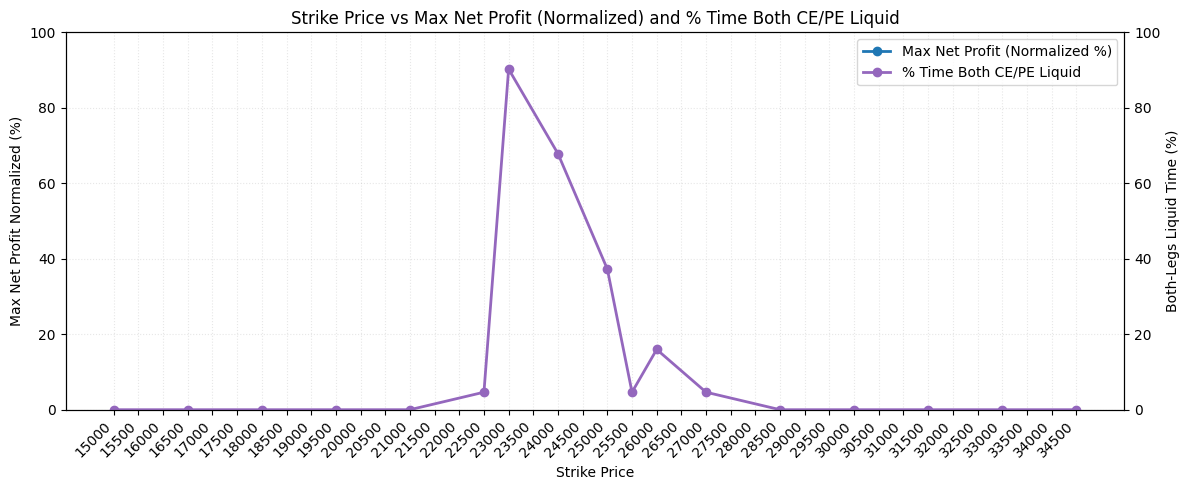

,strike_price,max_profit,max_profit_norm_pct,both_liquid_pct
0,15000,-272.946017,-33.980850,0.0
1,16500,-311.481599,-38.778399,0.0
2,18000,-349.978111,-43.571084,0.0
3,19500,-388.589094,-48.378020,0.0
4,21000,-356.685322,-44.406109,0.0


In [4]:
utils.plot_strike_vs_max_arbitrage_and_liquidity_pct(df, trading_cost=True).head()

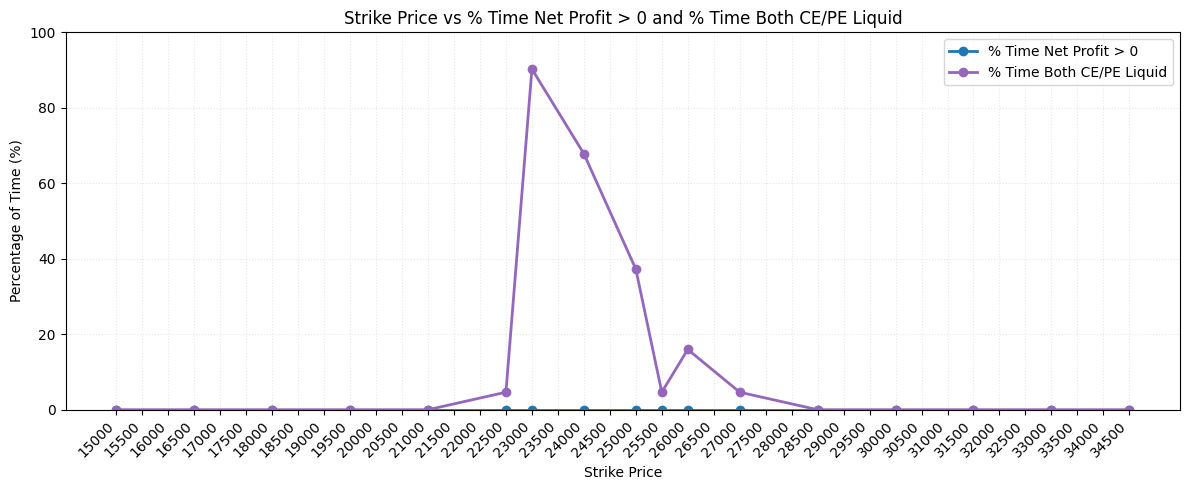

,strike_price,arbitrage_positive_pct,both_liquid_pct
0,15000,0.0,0.0
1,16500,0.0,0.0
2,18000,0.0,0.0
3,19500,0.0,0.0
4,21000,0.0,0.0


In [5]:
utils.plot_strike_vs_arbitrage_positive_and_liquidity_pct(df, trading_cost=True).head()

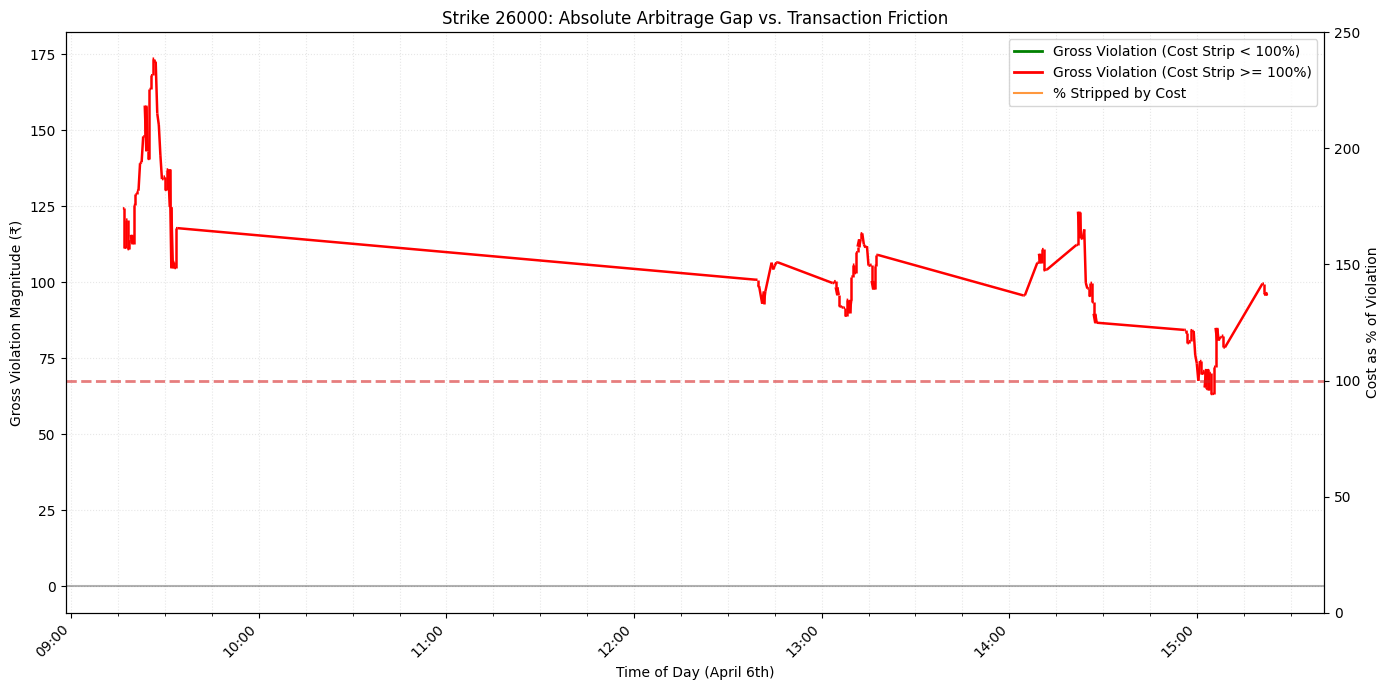

,fetch_time,abs_violation,cost,cost_stripped_pct
10,2026-04-10 09:16:30,124.277600,813.128416,654.283968
61,2026-04-10 09:17:00,124.279043,813.126852,654.275114
78,2026-04-10 09:17:00,111.379043,813.191977,730.112195
129,2026-04-10 09:17:30,111.380486,813.190413,730.101333
146,2026-04-10 09:17:30,120.580486,813.126764,674.343579
...,...,...,...,...
46046,2026-04-10 15:21:30,99.530821,812.719499,816.550579
46063,2026-04-10 15:21:30,96.680821,812.739648,840.642059
46131,2026-04-10 15:22:00,95.632264,812.745337,849.865203
46097,2026-04-10 15:22:00,96.682264,812.738082,840.627895


In [6]:
utils.plot_strike_abs_violation_vs_cost_stripped_pct(df[df['both_legs_liquid'] == True], strike=26000)

In [7]:
importlib.reload(utils)

<module 'utils' from 'd:\\finmod\\Nifty50-PutCallParity-Arbitrage\\utils.py'>

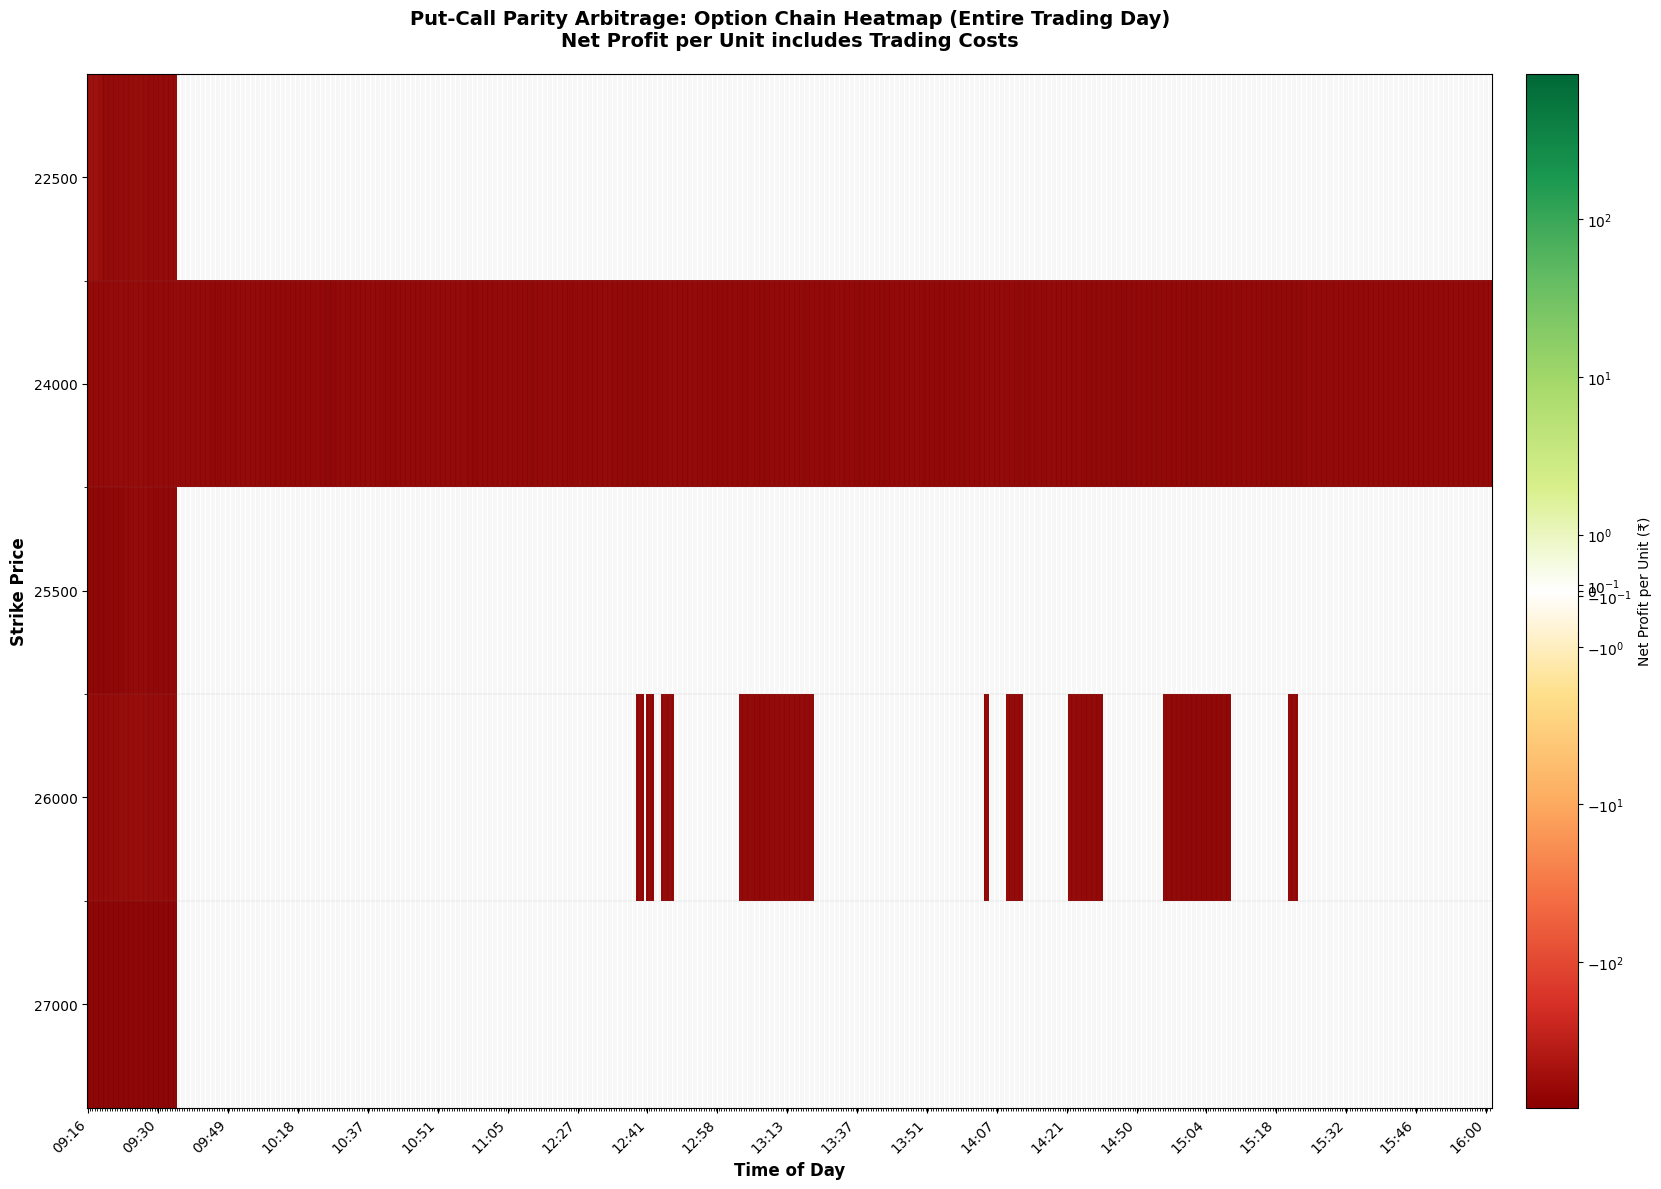

In [8]:
# COMPREHENSIVE HEATMAP: Entire Option Chain Over Entire Trading Day
# X-axis: Time of Day (09:15 to 15:30)
# Y-axis: Strike Prices (sorted)
# Color: Net Profit (Green=Profitable, Red=Loss, White=Break-even)

pivot_data = utils.plot_option_chain_heatmap_over_time(
    df[df['both_legs_liquid'] == True],  # Filter for options that were liquid at least 50% of the time
    min_liquidity=0,  # Include all data (change to e.g., 500 for more liquid options)
    trading_cost=True,
    figsize=(18, 12),
    efficiency_band_pct=0.001,  # Smaller neutral band for faster color transition
)

In [9]:
df.columns

Index(['fetch_time', 'symbol', 'expiry', 'spot_price', 'strike_price',
       'ce_growwContractId', 'ce_displayName', 'ce_longDisplayName',
       'ce_token', 'ce_marketLot', 'ce_liveData_close', 'ce_liveData_ltp',
       'ce_liveData_dayChange', 'ce_liveData_dayChangePerc', 'ce_liveData_oi',
       'ce_liveData_prevOI', 'ce_greeks_delta', 'ce_greeks_gamma',
       'ce_greeks_theta', 'ce_greeks_vega', 'ce_greeks_rho', 'ce_greeks_iv',
       'ce_greeks_pop', 'ce_markers', 'pe_growwContractId', 'pe_displayName',
       'pe_longDisplayName', 'pe_token', 'pe_marketLot', 'pe_liveData_close',
       'pe_liveData_ltp', 'pe_liveData_dayChange', 'pe_liveData_dayChangePerc',
       'pe_liveData_oi', 'pe_liveData_prevOI', 'pe_greeks_delta',
       'pe_greeks_gamma', 'pe_greeks_theta', 'pe_greeks_vega', 'pe_greeks_rho',
       'pe_greeks_iv', 'pe_greeks_pop', 'pe_markers', 'T', 'liquidity',
       'both_legs_liquid', 'both_legs_liquid_time_pct', 'market_side',
       'theoretical_side', 'violation

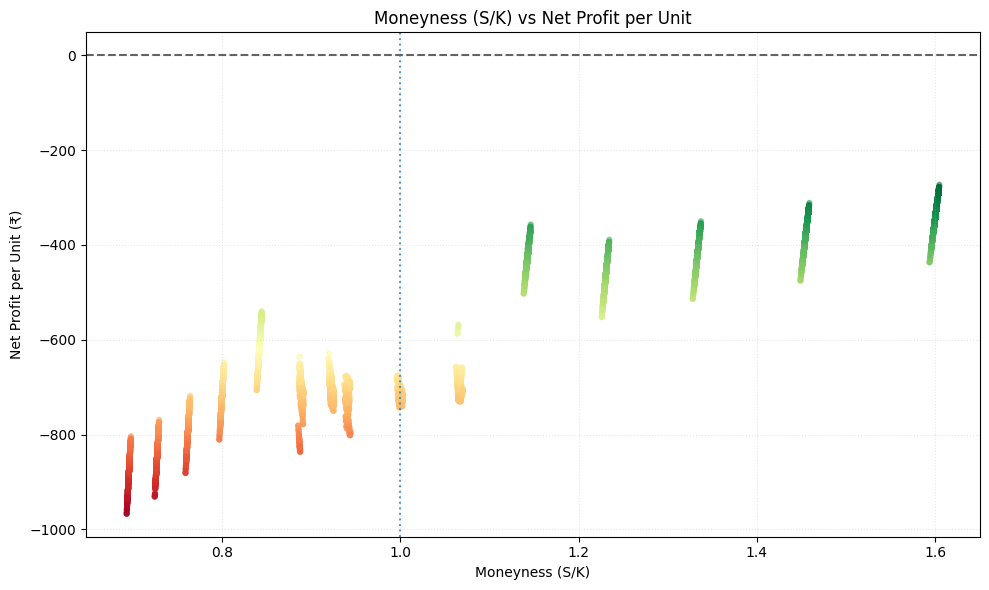

,moneyness,net_profit_per_unit
0,1.596370,-398.616202
1,1.451245,-437.143981
2,1.330308,-475.632689
3,1.227977,-514.235869
4,1.140264,-465.811916


In [10]:
# SCATTER: Moneyness (S/K) vs Net Profit per Unit
moneyness_df = utils.plot_moneyness_vs_net_profit(
    df,
    min_liquidity=0,
)
moneyness_df.head()

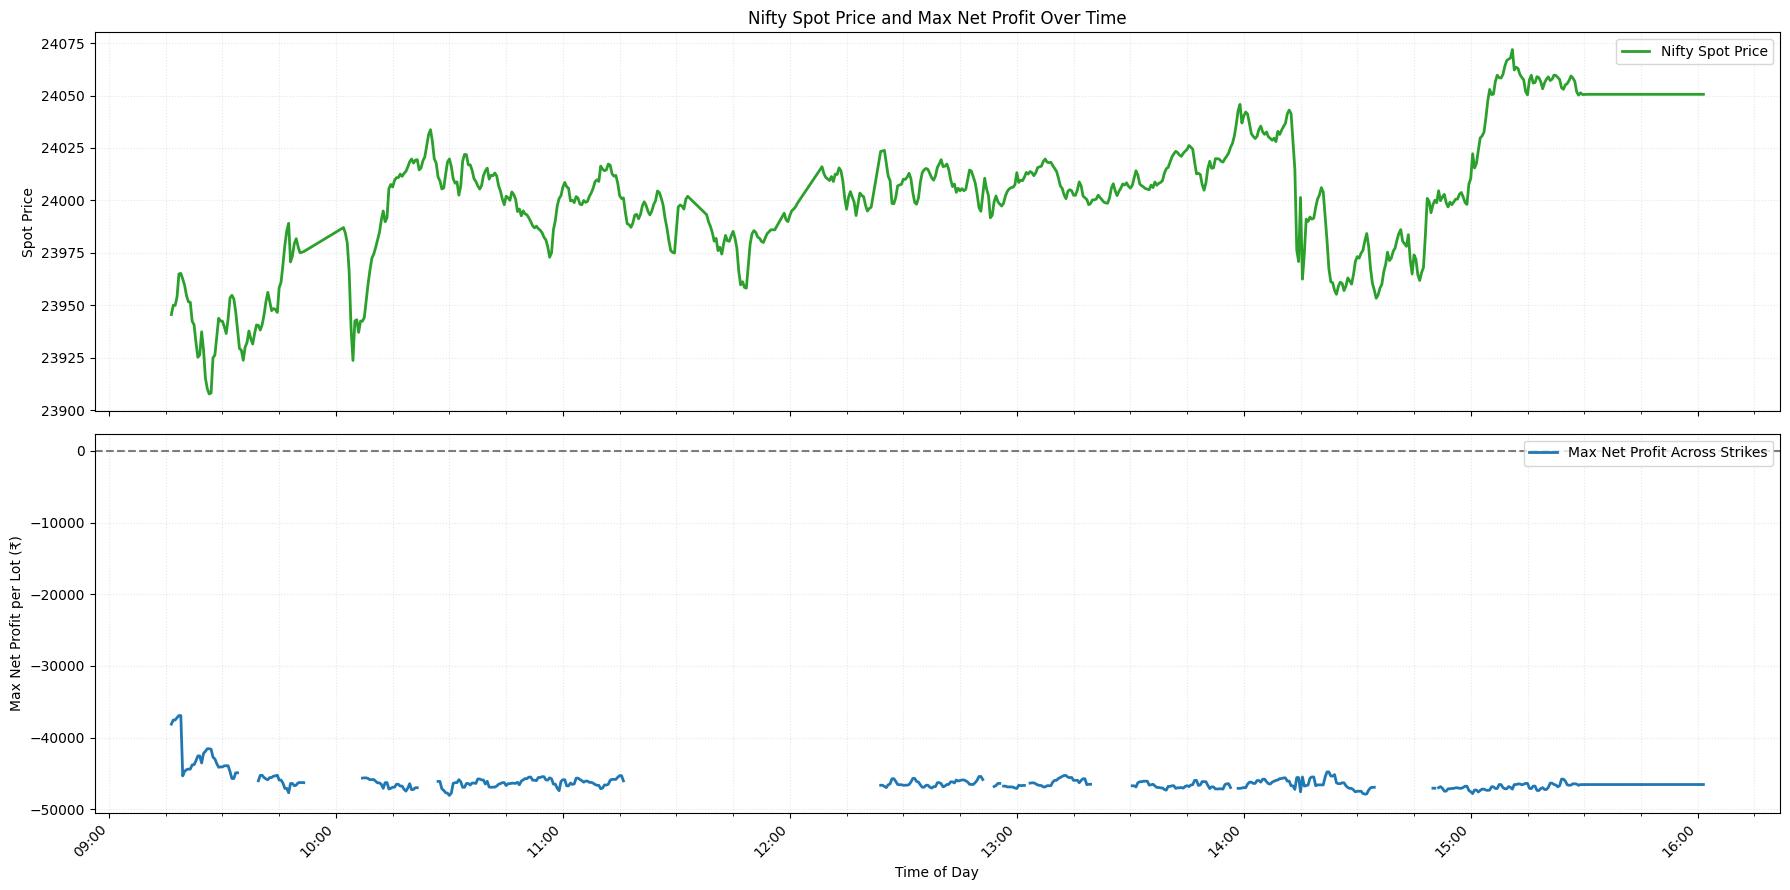

,fetch_time,spot_price,max_profit
0,2026-04-10 09:16:30,23945.550,-38122.939532
1,2026-04-10 09:17:00,23950.025,-37545.204691
2,2026-04-10 09:17:30,23949.900,-37545.195107
3,2026-04-10 09:18:00,23954.025,-37213.687400
4,2026-04-10 09:18:30,23964.950,-36929.656438


In [11]:
# TWO-PANEL VIEW: Spot Price (Top) and Max Net Profit Across Strikes (Bottom)
spot_profit_df = utils.plot_spot_and_max_profit_over_time(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    trading_cost=True,
    per_lot=True,
    figsize=(18, 9),
)
spot_profit_df.head()

In [12]:
# COST BREAKDOWN PIE: Average total_cost in profitable windows
cost_breakdown = utils.plot_avg_cost_breakdown_pie(
    df[df['both_legs_liquid'] == True],
    profitable_only=True,
    min_liquidity=0,
    per_lot=False,
)
cost_breakdown

ValueError: No rows available for the selected filter

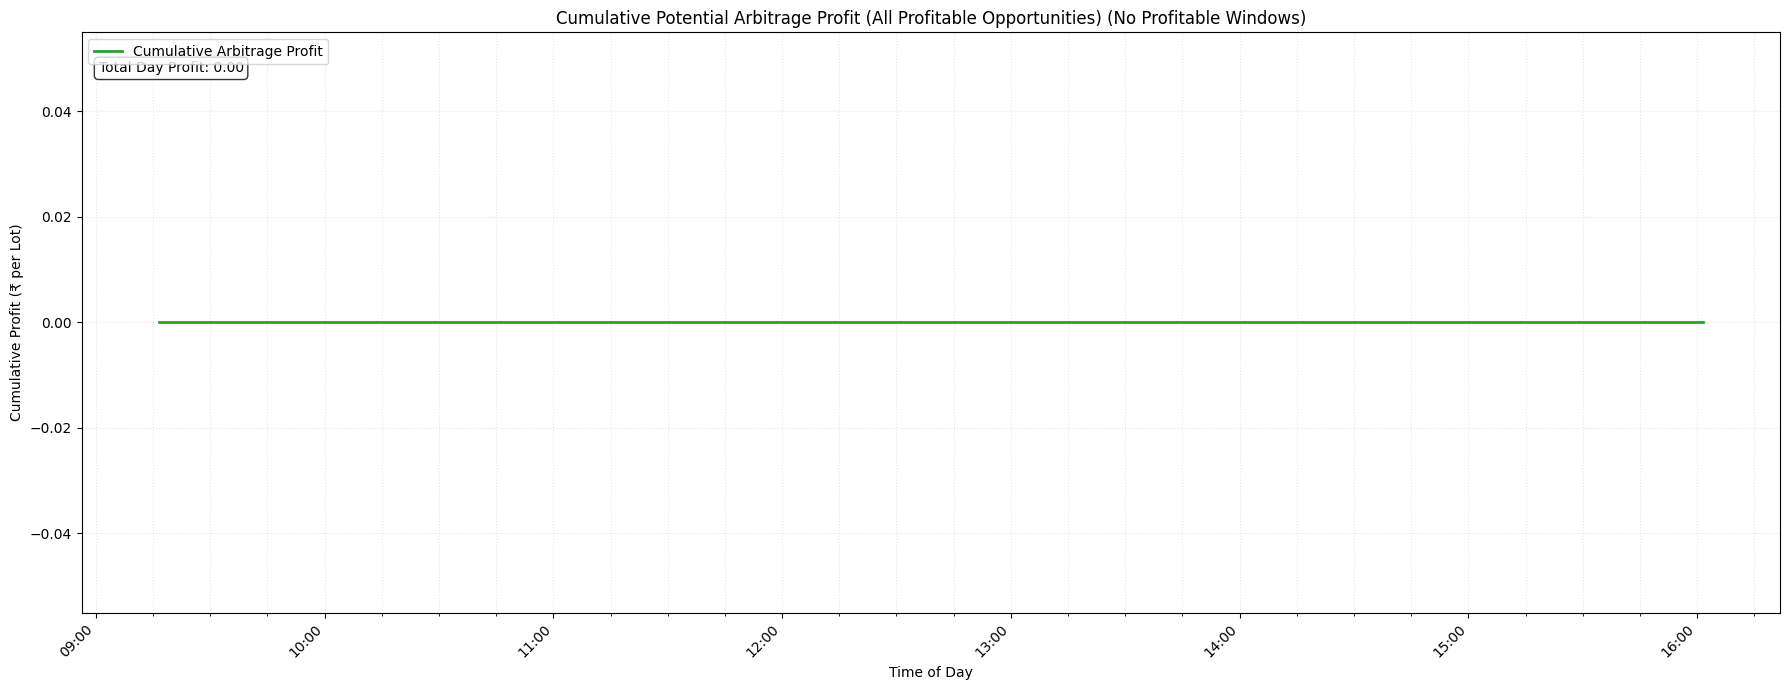

,fetch_time,interval_profit,opportunities_count,cumulative_profit
50819,2026-04-10 15:59:30,0.0,0,0.0
50887,2026-04-10 16:00:00,0.0,0,0.0
50938,2026-04-10 16:00:30,0.0,0,0.0
51006,2026-04-10 16:01:00,0.0,0,0.0
51074,2026-04-10 16:01:30,0.0,0,0.0


In [ ]:
# CUMSUM ARBITRAGE PROFIT: 1 lot at every profitable opportunity across strikes
cumsum_profit_df = utils.plot_cumsum_arbitrage_profit_all_opportunities(
     df[(df['both_legs_liquid'] == True)],
    require_liquid=True,
    min_liquidity=0,
    per_lot=True,
    figsize=(18, 7),
)
cumsum_profit_df.tail()